# 00 — Dân số theo tỉnh theo năm (WorldPop)

Luồng A1 — [PHASE-1-CHECKLIST.md §A1](../../PHASE-1-CHECKLIST.md). Tải raster WorldPop (`data.worldpop.org`, đã kiểm chứng 21/09/2026), cộng dồn về 34 tỉnh bằng zonal sum, xuất `data/interim/population_by_province_year.parquet` cho `build_panel.py` dùng.

**Trước khi chạy toàn bộ:** WorldPop chỉ phủ năm **2000-2020**, mỗi năm ~150-200MB → tải hết 21 năm tốn ~3-4GB — đã đo thật 1 năm ~13 phút ở mạng máy dev, nên cả 21 năm có thể mất vài giờ, không phải vài phút. Cứ để chạy nền, cell tự bỏ qua năm đã tải nếu chạy lại giữa chừng. Cell dưới có biến `YEARS` — đổi thành khoảng nhỏ (vd `range(2018, 2021)`) để chạy thử nhanh trước, rồi đổi lại full range khi chắc chắn pipeline chạy đúng.

In [1]:
import sys
from pathlib import Path

_root = Path.cwd()
if not (_root / "app").exists():
    _root = _root.parent
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))
print("project root:", _root)

project root: d:\Cuộc thi\DengueSense\ai-service


In [2]:
from app.data.ingest_population import (
    WORLDPOP_COVERAGE,
    build_worldpop_panel,
    extend_to_full_range,
)

print(f"WorldPop coverage: {WORLDPOP_COVERAGE}")

WorldPop coverage: (2000, 2020)


In [3]:
# Đổi range(2000, 2021) -> range(2018, 2021) để test nhanh trước.
YEARS = range(2000, 2021)

worldpop_panel = build_worldpop_panel(years=YEARS)
worldpop_panel.head()

[population 1/21] 2000: OK (77,999,036 người)
[population 2/21] 2001: OK (78,704,625 người)
[population 3/21] 2002: OK (79,456,579 người)
[population 4/21] 2003: OK (80,226,906 người)
[population 5/21] 2004: OK (81,030,977 người)
[population 6/21] 2005: OK (81,865,111 người)
[population 7/21] 2006: OK (82,736,141 người)
[population 8/21] 2007: OK (83,650,878 người)
[population 9/21] 2008: OK (84,576,591 người)
[population 10/21] 2009: OK (85,547,570 người)
[population 11/21] 2010: OK (86,570,719 người)
[population 12/21] 2011: OK (87,616,433 người)
[population 13/21] 2012: OK (88,711,964 người)
[population 14/21] 2013: OK (89,858,913 người)
[population 15/21] 2014: OK (91,024,249 người)
[population 16/21] 2015: OK (92,239,755 người)
[population 17/21] 2016: OK (93,493,657 người)
[population 18/21] 2017: OK (94,808,324 người)
[population 19/21] 2018: OK (96,170,483 người)
[population 20/21] 2019: OK (97,582,504 người)
[population 21/21] 2020: OK (99,037,315 người)


,province_id,year,population,population_source
0,an_giang,2000,3467576,estimated
1,bac_ninh,2000,2446009,estimated
2,ca_mau,2000,1867239,estimated
3,can_tho,2000,3002002,estimated
4,cao_bang,2000,489340,estimated


## Mở rộng ra 1994-2025

Năm ngoài phạm vi WorldPop lấy giá trị năm gần nhất đã biết (carry-forward/backward), gắn `population_source='imputed'` — khác `'estimated'` của năm có raster thật. Không được gộp 2 loại này khi báo cáo (xem [docs/01 §8](../../docs/01-chien-luoc-du-lieu.md#8)).

In [4]:
population_panel = extend_to_full_range(worldpop_panel, range(1994, 2026))
population_panel['population_source'].value_counts()

population_source
estimated    714
imputed      374
Name: count, dtype: int64

## Sanity check

Tổng dân số Việt Nam phải nằm trong khoảng hợp lý (~70 triệu năm 1994 → ~100 triệu năm gần đây). Ra số âm, bằng 0, hoặc hàng tỉ là có bug (đơn vị, merge sai, raster đọc nhầm).

year
1994    77999036
2000    77999036
2010    86570719
2020    99037315
2025    99037315
Name: population, dtype: Int64


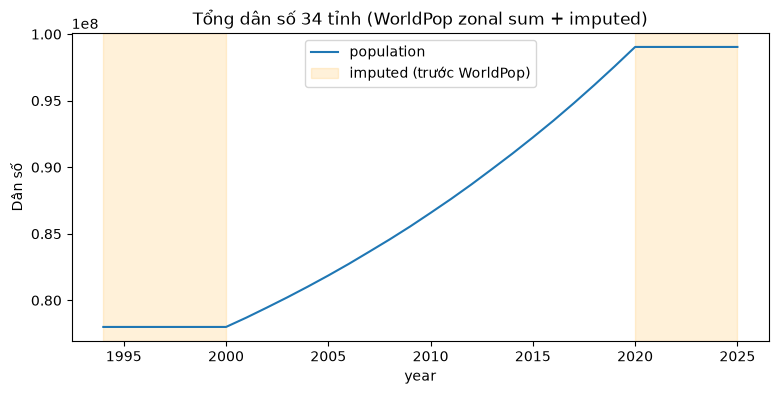

In [5]:
import matplotlib.pyplot as plt

yearly_total = population_panel.groupby('year')['population'].sum()
print(yearly_total.loc[[1994, 2000, 2010, 2020, 2025]])

fig, ax = plt.subplots(figsize=(9, 4))
yearly_total.plot(ax=ax)
ax.set_title('Tổng dân số 34 tỉnh (WorldPop zonal sum + imputed)')
ax.set_ylabel('Dân số')
ax.axvspan(1994, WORLDPOP_COVERAGE[0], alpha=0.15, color='orange', label='imputed (trước WorldPop)')
ax.axvspan(WORLDPOP_COVERAGE[1], 2025, alpha=0.15, color='orange')
ax.legend()
plt.show()

In [6]:
assert 60_000_000 < yearly_total.min() < 110_000_000, "Tổng dân số ra ngoài khoảng hợp lý — kiểm tra lại trước khi lưu"
print('Sanity check pass.')

Sanity check pass.


## Lưu ra `data/interim/`

In [7]:
from pathlib import Path

interim_dir = _root / 'data' / 'interim'
interim_dir.mkdir(parents=True, exist_ok=True)
out_path = interim_dir / 'population_by_province_year.parquet'
population_panel.to_parquet(out_path, index=False)
print(f'Đã lưu {len(population_panel)} dòng vào {out_path}')

Đã lưu 1088 dòng vào d:\Cuộc thi\DengueSense\ai-service\data\interim\population_by_province_year.parquet


**Tiếp theo:** chạy `01_ingest_oni.ipynb` và `02_ingest_era5.ipynb`, sau đó `python -m app.data.build_panel` từ `ai-service/` để ghép panel v0.2.0.